<a href="https://colab.research.google.com/github/lsapienza/lsapienza-blog/blob/main/C%C3%B3pia_de_nucleo_ipca.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bibliotecas e utilidades

In [ ]:
!pip install python-bcb

In [ ]:
from bcb import sgs
import pandas as pd
import numpy as np
import locale
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from plotnine import *
import statsmodels.api as sm




In [ ]:
# Cores para gráficos
colors = {'blue':'#282f6b',
          'red':'#b22200',
          'green':'#224f2-',
          'purple':'#5f487c',
          'gray':'#66666',
          'orange':'#b35c1e',
          }

# Coleta de dados

In [ ]:
# Importa os dados
nucleos_df =sgs.get({'ex0':11427, 'ex3':27839, 'dp':16122,'ms':4466, 'p55':28750, 'ipca':433}, start='2002-01-01')
print(nucleos_df)


             ex0   ex3    dp    ms   p55  ipca
Date                                          
2002-01-01  0.49  0.44  0.57  0.52  0.60  0.52
2002-02-01  0.84  0.51  0.53  0.54  0.42  0.36
2002-03-01  0.43  0.55  0.54  0.58  0.61  0.60
2002-04-01  0.51  0.53  0.54  0.56  0.52  0.80
2002-05-01  0.53  0.53  0.40  0.51  0.46  0.21
...          ...   ...   ...   ...   ...   ...
2026-03-01  0.45  0.39  0.46  0.41  0.46  0.88
2026-04-01  0.26  0.63  0.51  0.48  0.59  0.67
2026-05-01  0.37  0.58  0.38  0.43  0.48  0.58
2026-06-01  0.25  0.22  0.15  0.24  0.18  0.16
2026-07-01  0.30  0.25  0.17  0.29  0.28  0.07

[295 rows x 6 columns]


# Tratamento de dados

In [ ]:
# Define os núcleos
nucleos = nucleos_df.copy()

# Calcula a média dos núcleos
nucleos['media_nucleos'] = nucleos.drop('ipca',axis=1).mean(axis=1)

# Obter o nome do mês
nucleos['mes']=nucleos.index.month_name()


# Calcular a media para cada mês
media_m = nucleos.groupby('mes')['media_nucleos'].mean()

# Calcular o percentil 20 e 80 para cada mês
percentil_20 = nucleos.groupby('mes')['media_nucleos'].quantile(0.2)
percentil_80 = nucleos.groupby('mes')['media_nucleos'].quantile(0.8)

# Criar um Dataframe com os resultados
resultados = pd.DataFrame({
    'mes': media_m.index,
    'media_m': media_m.values,
    'percentil_20': percentil_20.values,
    'percentil_80': percentil_80.values
})

# Obtém valores do ano atual
nucleos_m = (nucleos
             .query('index >= "2026-01-01"')
             .reset_index()
             [['mes','media_nucleos','ipca']]
             )

# Junta os resultados
df_nucleos = pd.merge(left = resultados, right = nucleos_m, how = 'outer')
print(df_nucleos)


          mes   media_m  percentil_20  percentil_80  media_nucleos  ipca
0       April  0.497840        0.3036        0.6432          0.494  0.67
1      August  0.376667        0.2360        0.4900            NaN   NaN
2    December  0.607167        0.4092        0.6888            NaN   NaN
3    February  0.563520        0.3960        0.7244          0.620  0.70
4     January  0.570160        0.4228        0.6776          0.448  0.33
5        July  0.344880        0.1896        0.4700          0.258  0.07
6        June  0.391280        0.2220        0.5564          0.208  0.16
7       March  0.476240        0.2728        0.6336          0.434  0.88
8         May  0.474560        0.2992        0.6424          0.448  0.58
9    November  0.450583        0.2348        0.5932            NaN   NaN
10    October  0.477583        0.3172        0.5708            NaN   NaN
11  September  0.396250        0.2396        0.5680            NaN   NaN


In [ ]:
import pandas as pd

# 1. Criar a lista de referência na ordem cronológica correta (em português)
ordem_siglas_pt = [
    "Jan",
    "Fev",
    "Mar",
    "Abr",
    "Mai",
    "Jun",
    "Jul",
    "Ago",
    "Set",
    "Out",
    "Nov",
    "Dez",
]

# 2. Cortar os valores atuais para 3 letras (caso ainda estejam longos)
df_nucleos["mes"] = df_nucleos["mes"].astype(str).str.slice(stop=3)

# 3. Corrigir pequenas variações de tradução (ex: se houver "May", vira "Mai")
traducao_meses = {
    "Jan": "Jan",
    "Feb": "Fev",
    "Mar": "Mar",
    "Apr": "Abr",
    "May": "Mai",
    "Jun": "Jun",
    "Jul": "Jul",
    "Aug": "Ago",
    "Sep": "Set",
    "Oct": "Out",
    "Nov": "Nov",
    "Dec": "Dez",
    "Jan": "Jan",
    "Fev": "Fev",
    "Mar": "Mar",
    "Abr": "Abr",
    "Mai": "Mai",
    "Jun": "Jun",
    "Jul": "Jul",
    "Ago": "Ago",
    "Set": "Set",
    "Out": "Out",
    "Nov": "Nov",
    "Dez": "Dez",
}
df_nucleos["mes"] = df_nucleos["mes"].map(traducao_meses)

# 4. Transformar em categoria usando a lista de referência (isso força a ordenação correta)
df_nucleos["mes"] = pd.Categorical(
    df_nucleos["mes"], categories=ordem_siglas_pt, ordered=True
)

# 5. Ordenar o DataFrame de forma definitiva
df_nucleos = df_nucleos.sort_values(by="mes").reset_index(drop=True)

print(df_nucleos)


    mes   media_m  percentil_20  percentil_80  media_nucleos  ipca
0   Jan  0.570160        0.4228        0.6776          0.448  0.33
1   Fev  0.563520        0.3960        0.7244          0.620  0.70
2   Mar  0.476240        0.2728        0.6336          0.434  0.88
3   Abr  0.497840        0.3036        0.6432          0.494  0.67
4   Mai  0.474560        0.2992        0.6424          0.448  0.58
5   Jun  0.391280        0.2220        0.5564          0.208  0.16
6   Jul  0.344880        0.1896        0.4700          0.258  0.07
7   Ago  0.376667        0.2360        0.4900            NaN   NaN
8   Set  0.396250        0.2396        0.5680            NaN   NaN
9   Out  0.477583        0.3172        0.5708            NaN   NaN
10  Nov  0.450583        0.2348        0.5932            NaN   NaN
11  Dez  0.607167        0.4092        0.6888            NaN   NaN


In [ ]:
# Obter a lista de todos os meses presentes nos dados e ordená-los
#ordem_meses = sorted(df_nucleos['mes'].unique(), key=lambda x: pd.to_datetime(x, format='%B'))

# Ordena os dados de acordo com a ordem dos meses
#df_nucleos['mes']= pd.Categorical(df_nucleos['mes'],categories=ordem_meses, ordered=True)
#df_nucleos=df_nucleos.sort_values(by='mes')

#Cortar os valores da coluna 'mes'
#df_nucleos['mes'] = df_nucleos['mes'].str.slice(stop=3)

#print(df_nucleos)


# Variação Mensal do Núcleo

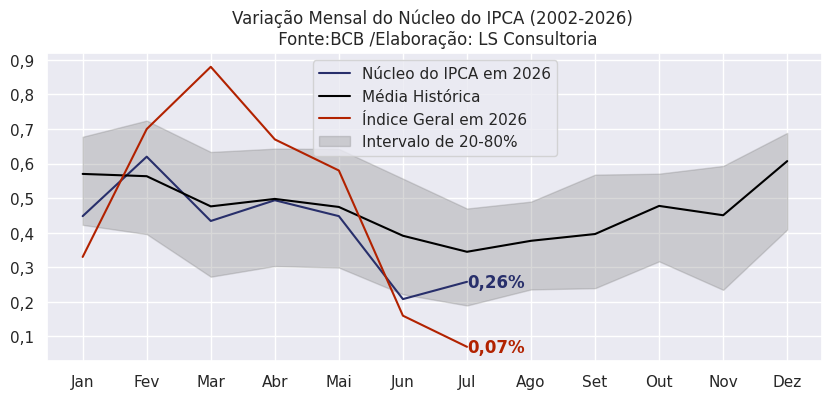

In [ ]:
# Configurar o estilo do seaborn
sns.set()

# Definier o tamanho da figura
plt.figure(figsize=(10,4)) #Ajuste a largura e altura conforme necessário

#Plotar as linhas
sns.lineplot(data=df_nucleos, x='mes', y='media_nucleos', color='#282f6b', label='Núcleo do IPCA em 2026')
sns.lineplot(data=df_nucleos, x='mes', y='media_m', color='black', label='Média Histórica')
sns.lineplot(data=df_nucleos, x='mes', y='ipca', color='#b22200', label='Índice Geral em 2026')

#Preencher a área entre os percentis 20 e 80
plt.fill_between(df_nucleos['mes'], df_nucleos['percentil_20'], df_nucleos['percentil_80'], color='grey', alpha=0.3, label='Intervalo de 20-80%')

# --- ADICIONAR VALOR NO ÚLTIMO PONTO DAS DUAS SÉRIES ---

# 1. Rótulo para a série: Núcleo do IPCA (Linha Azul)
ponto_nucleo = df_nucleos[df_nucleos["media_nucleos"].notna()].iloc[-1]
texto_nucleo = f"{ponto_nucleo['media_nucleos']:.2f}%".replace(".", ",")

plt.text(
    x=ponto_nucleo["mes"],
    y=ponto_nucleo["media_nucleos"] + 0.0,  # Ajuste para ficar acima da linha
    s=texto_nucleo,
    color="#282f6b",
    weight="bold",
    ha="left",  # Alinha o início do texto à esquerda, jogando o corpo dele para a direita
    va="center",  # Centraliza o texto verticalmente na altura do +0.07
)

# 2. Rótulo para a série: Índice Geral IPCA (Linha Vermelha)
ponto_ipca = df_nucleos[df_nucleos["ipca"].notna()].iloc[-1]
texto_ipca = f"{ponto_ipca['ipca']:.2f}%".replace(".", ",")

plt.text(
    x=ponto_ipca["mes"],
    y=ponto_ipca["ipca"] ,  # Ajuste negativo caso queira colocar abaixo da linha se elas cruzarem
    s=texto_ipca,
    color="#b22200",
    weight="bold",
    ha= "left",  # Alinha o início do texto à esquerda, jogando o corpo dele para a direita
    va="center",  # Centraliza o texto verticalmente na altura do +0.07
)
# --------------------------------------------------------
# --- FORMATAR EIXO Y COM VÍRGULA ---
# Altera o ponto por vírgula mantendo 1 casa decimal (ajuste o .1f se precisar de mais casas)
formatter = ticker.FuncFormatter(lambda x, pos: f"{x:.1f}".replace(".", ","))
plt.gca().yaxis.set_major_formatter(formatter)
# -----------------------------------

# Adicionar legenda
plt.legend()

# Remover os nomes dos eixos x e y
plt.title('Variação Mensal do Núcleo do IPCA (2002-2026) \n Fonte:BCB /Elaboração: LS Consultoria')
plt.xlabel(None)
plt.ylabel(None)

#Exibir o gráfico
plt.show()


# Variação Acumulada e SAAR

In [ ]:

# Função para acumular valores em janelas móveis
def acum_p(data, n):
  """
  Calcula a acumulação de variações percentuais em janela móveis.

  Argumentos:
  - data: array-like
    Uma sequência de dados representando variações percentuais.

  -n: int
    O tamanho da janela móvel para os cálculo de acumulação.

  Retorno:
  - array
      Um array contendo a acumulação das variações percentuais em janelas móveis.
  """
  resultado = (((data / 100)+1)
                .rolling(window= n)
                .apply(np.prod)
                -1) *100

  return resultado

In [ ]:
# Realiza a decomposição (aditiva)
decomposition = sm.tsa.seasonal_decompose(nucleos.media_nucleos, model  = 'additive')

nucleos['nucleos_sa'] = nucleos.media_nucleos.values - decomposition.seasonal.values

In [ ]:
# Cálcula Acumulado e Média Móvel
dados = (
    nucleos
    .assign(nucleos_12m = lambda x: acum_p(x.media_nucleos, 12)) # acumula 3m 12 meses
    .assign(nucleos_mm3m = lambda x: x.nucleos_sa.rolling(window = 3).mean() * 12 # média móvel de 3 meses e anualiza

)
    .reset_index()
    .dropna()
)
print(dados)

          Date   ex0   ex3    dp    ms   p55  ipca  media_nucleos       mes  \
11  2002-12-01  1.66  1.82  1.72  1.36  1.74  2.10          1.660  December   
12  2003-01-01  1.39  1.45  1.80  1.32  1.71  2.25          1.534   January   
13  2003-02-01  0.99  0.66  1.32  0.93  0.69  1.57          0.918  February   
14  2003-03-01  1.12  1.35  1.19  1.23  0.89  1.23          1.156     March   
15  2003-04-01  0.81  0.99  0.97  1.10  0.81  0.97          0.936     April   
..         ...   ...   ...   ...   ...   ...   ...            ...       ...   
290 2026-03-01  0.45  0.39  0.46  0.41  0.46  0.88          0.434     March   
291 2026-04-01  0.26  0.63  0.51  0.48  0.59  0.67          0.494     April   
292 2026-05-01  0.37  0.58  0.38  0.43  0.48  0.58          0.448       May   
293 2026-06-01  0.25  0.22  0.15  0.24  0.18  0.16          0.208      June   
294 2026-07-01  0.30  0.25  0.17  0.29  0.28  0.07          0.258      July   

     nucleos_sa  nucleos_12m  nucleos_mm3m  
11    

In [ ]:
import pandas as pd
from bcb import sgs

# 1. Baixa a série anual da meta de inflação (Código SGS: 13521)
df_anual = sgs.get({'meta_inflacao': 13521}, start='2000-01-01')

# 2. Cria um índice mensal cobrindo todo o intervalo da série anual
# Usamos 'MS' (Month Start) para definir o dia 1º de cada mês
indice_mensal = pd.date_range(
    start=df_anual.index.min().strftime('%Y-01-01'),
    end=df_anual.index.max().strftime('%Y-12-31'),
    freq='MS'
)

# 3. Reindexa a série anual para o formato mensal (gerando linhas com NaN)
df_mensal = df_anual.reindex(indice_mensal)

# 4. Preenche os valores vazios repetindo o valor do respectivo ano
# Como o BCB geralmente entrega a data como 01/01, usamos ffill()
df_mensal['meta_inflacao'] = df_mensal['meta_inflacao'].ffill()
# 1. Pega o valor da meta e calcula os limites (+1.5% e -1.5%)
df_mensal['limite_superior'] = df_mensal['meta_inflacao'] + 1.5
df_mensal['limite_inferior'] = df_mensal['meta_inflacao'] - 1.5

# Se os dados do BCB vierem com a data em 31/12, use .bfill() no lugar de .ffill()

print(df_mensal.head(15))


            meta_inflacao  limite_superior  limite_inferior
2000-01-01            6.0              7.5              4.5
2000-02-01            6.0              7.5              4.5
2000-03-01            6.0              7.5              4.5
2000-04-01            6.0              7.5              4.5
2000-05-01            6.0              7.5              4.5
2000-06-01            6.0              7.5              4.5
2000-07-01            6.0              7.5              4.5
2000-08-01            6.0              7.5              4.5
2000-09-01            6.0              7.5              4.5
2000-10-01            6.0              7.5              4.5
2000-11-01            6.0              7.5              4.5
2000-12-01            6.0              7.5              4.5
2001-01-01            4.0              5.5              2.5
2001-02-01            4.0              5.5              2.5
2001-03-01            4.0              5.5              2.5


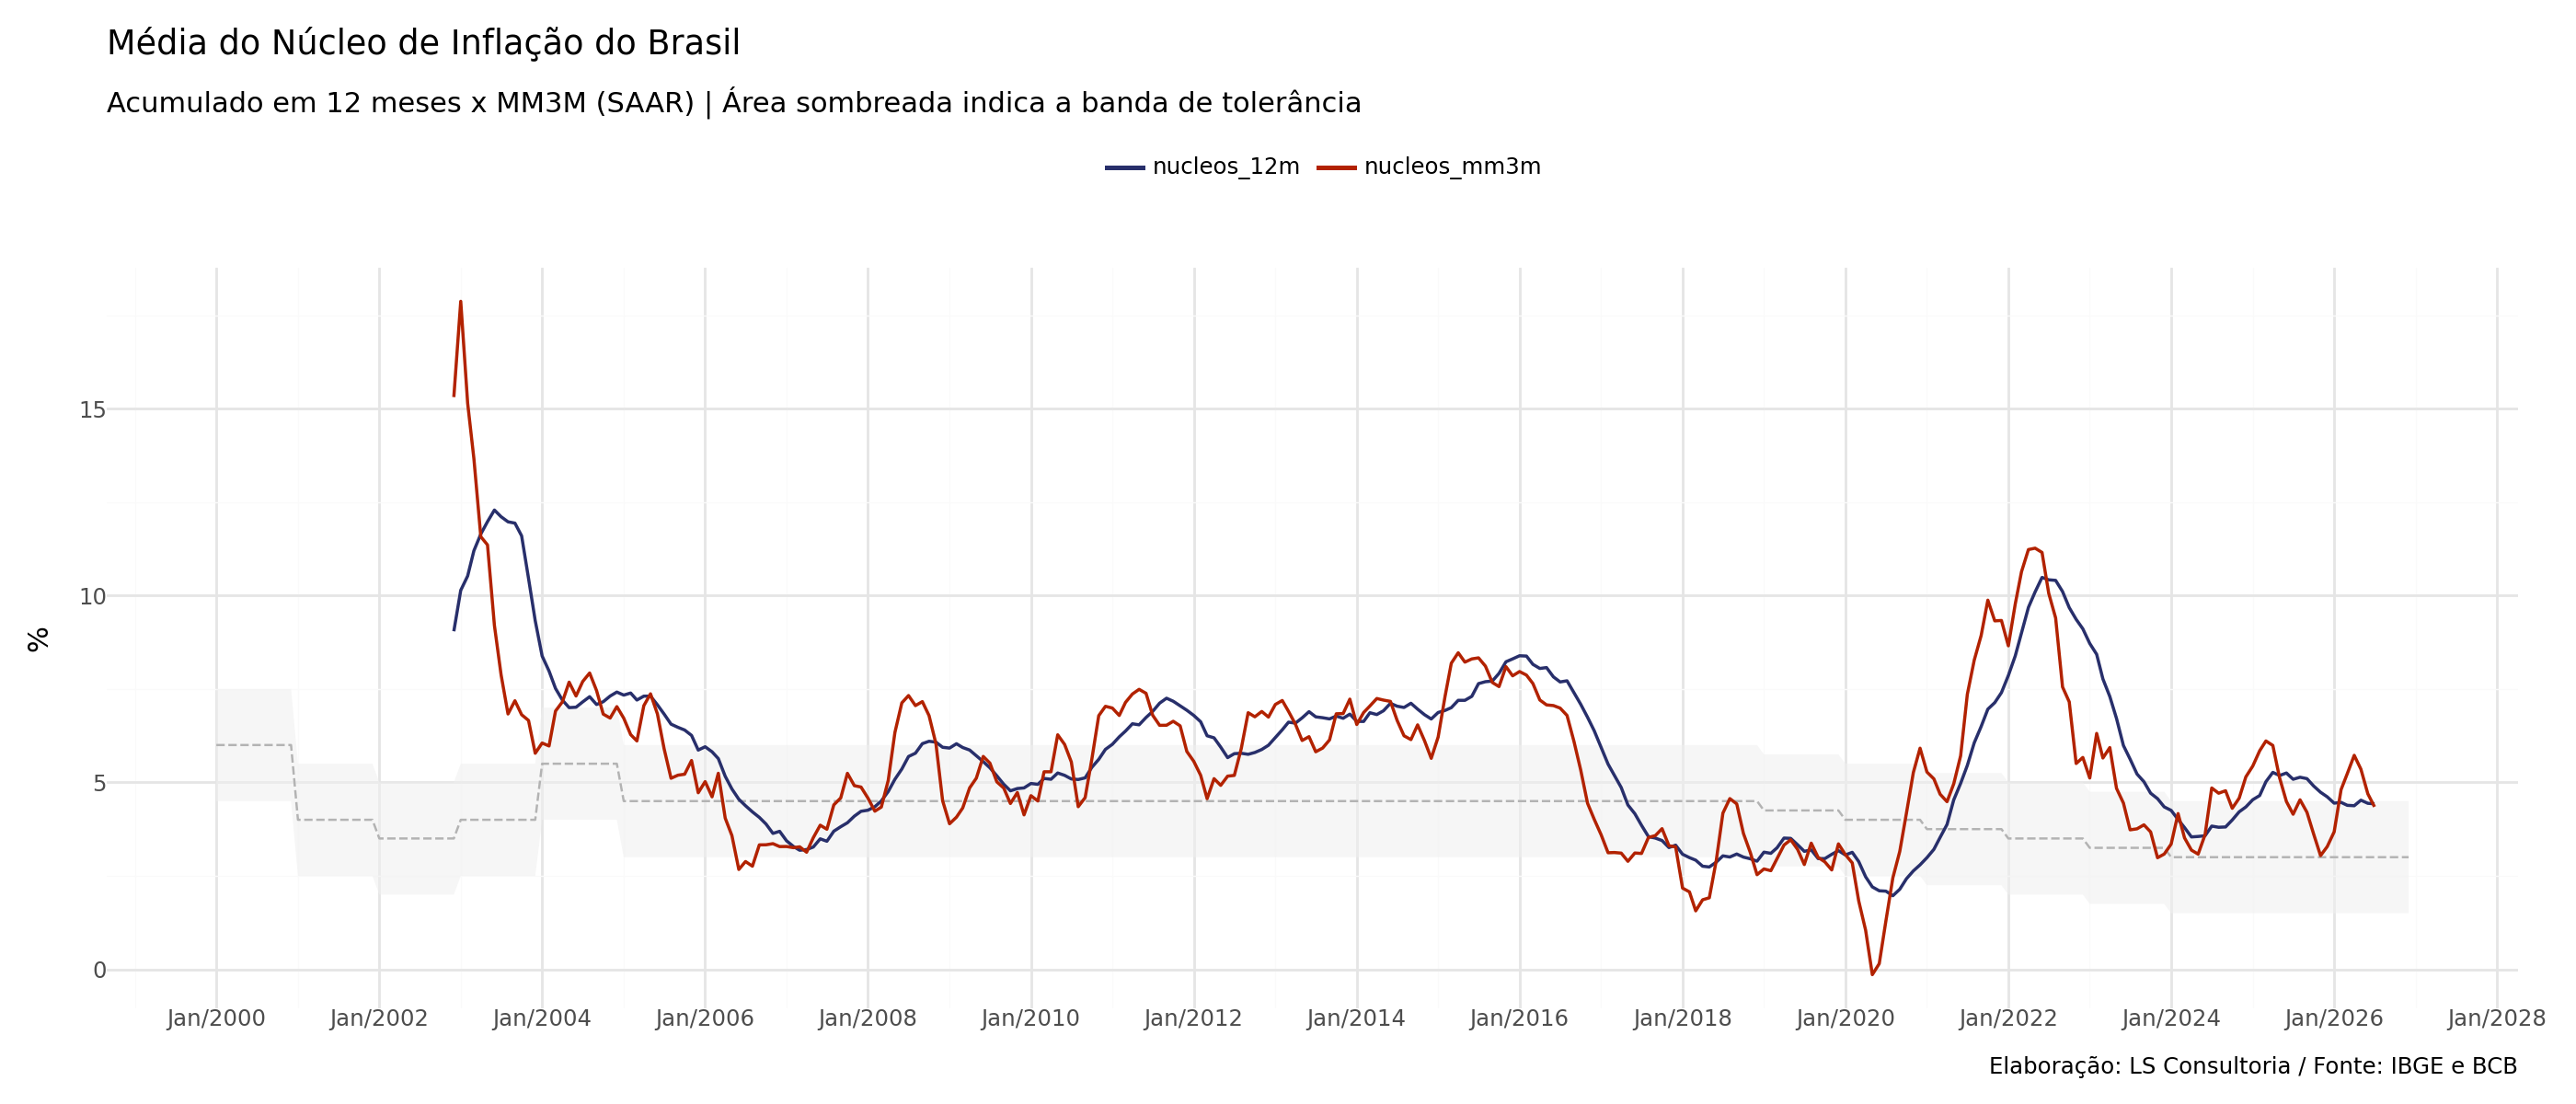

In [ ]:
from mizani.breaks import breaks_date
from plotnine import ggplot, geom_ribbon, geom_line, aes, scale_color_manual, scale_x_date, labs, theme_minimal, theme

# Certifique-se de que o seu DataFrame 'dados' possui as colunas:
# 'Date', 'meta', 'limite_sup', 'limite_inf', 'nucleos_12m' e 'nucleos_mm3m'

# 1. Transforma APENAS as variáveis dos núcleos para formato long
dados_long = dados[['Date','nucleos_12m','nucleos_mm3m']].melt(id_vars = ['Date'])

# 2. Cria o gráfico com a sombra ao fundo
(
    ggplot() +
    # Camada 1 (FUNDO ABSOLUTO): Cria a sombra cinza claro entre as bandas de tolerância
    geom_ribbon(
        data=df_mensal_plot, # Usando df_mensal_plot que contém os limites da meta
        mapping=aes(x='Date', ymin='limite_inferior', ymax='limite_superior'), # Nomes de colunas corrigidos
        fill='#f0f0f0',
        alpha=0.6
    ) +

    # Camada 2 (MEIO): Linha tracejada sutil apenas para a meta central
    geom_line(data=df_mensal_plot, mapping=aes(x='Date', y='meta_inflacao'), color='#b3b3b3', linetype='dashed', size=0.5) + # Nomes de colunas e `mapping=aes` corrigidos

    # Camada 3 (FRENTE): Linhas principais dos núcleos de inflação (formato longo)
    geom_line(data=dados_long, mapping=aes(x='Date', y='value', color='variable'), size=0.7) + # `mapping=aes` corrigido

    # Customizações e formatações (Corrigido para evitar o FutureWarning)
    scale_color_manual(values = list(colors.values())) +
    scale_x_date(breaks = breaks_date(width="2 years"), date_labels = "%b/%Y") +

    labs(title = f"Média do Núcleo de Inflação do Brasil",
         subtitle = "Acumulado em 12 meses x MM3M (SAAR) | Área sombreada indica a banda de tolerância",
         color = "",
         x="",
         y="%",
         caption = "Elaboração: LS Consultoria / Fonte: IBGE e BCB") +
    theme_minimal() +
    theme(figure_size=(14,6),
          legend_position="top")
)

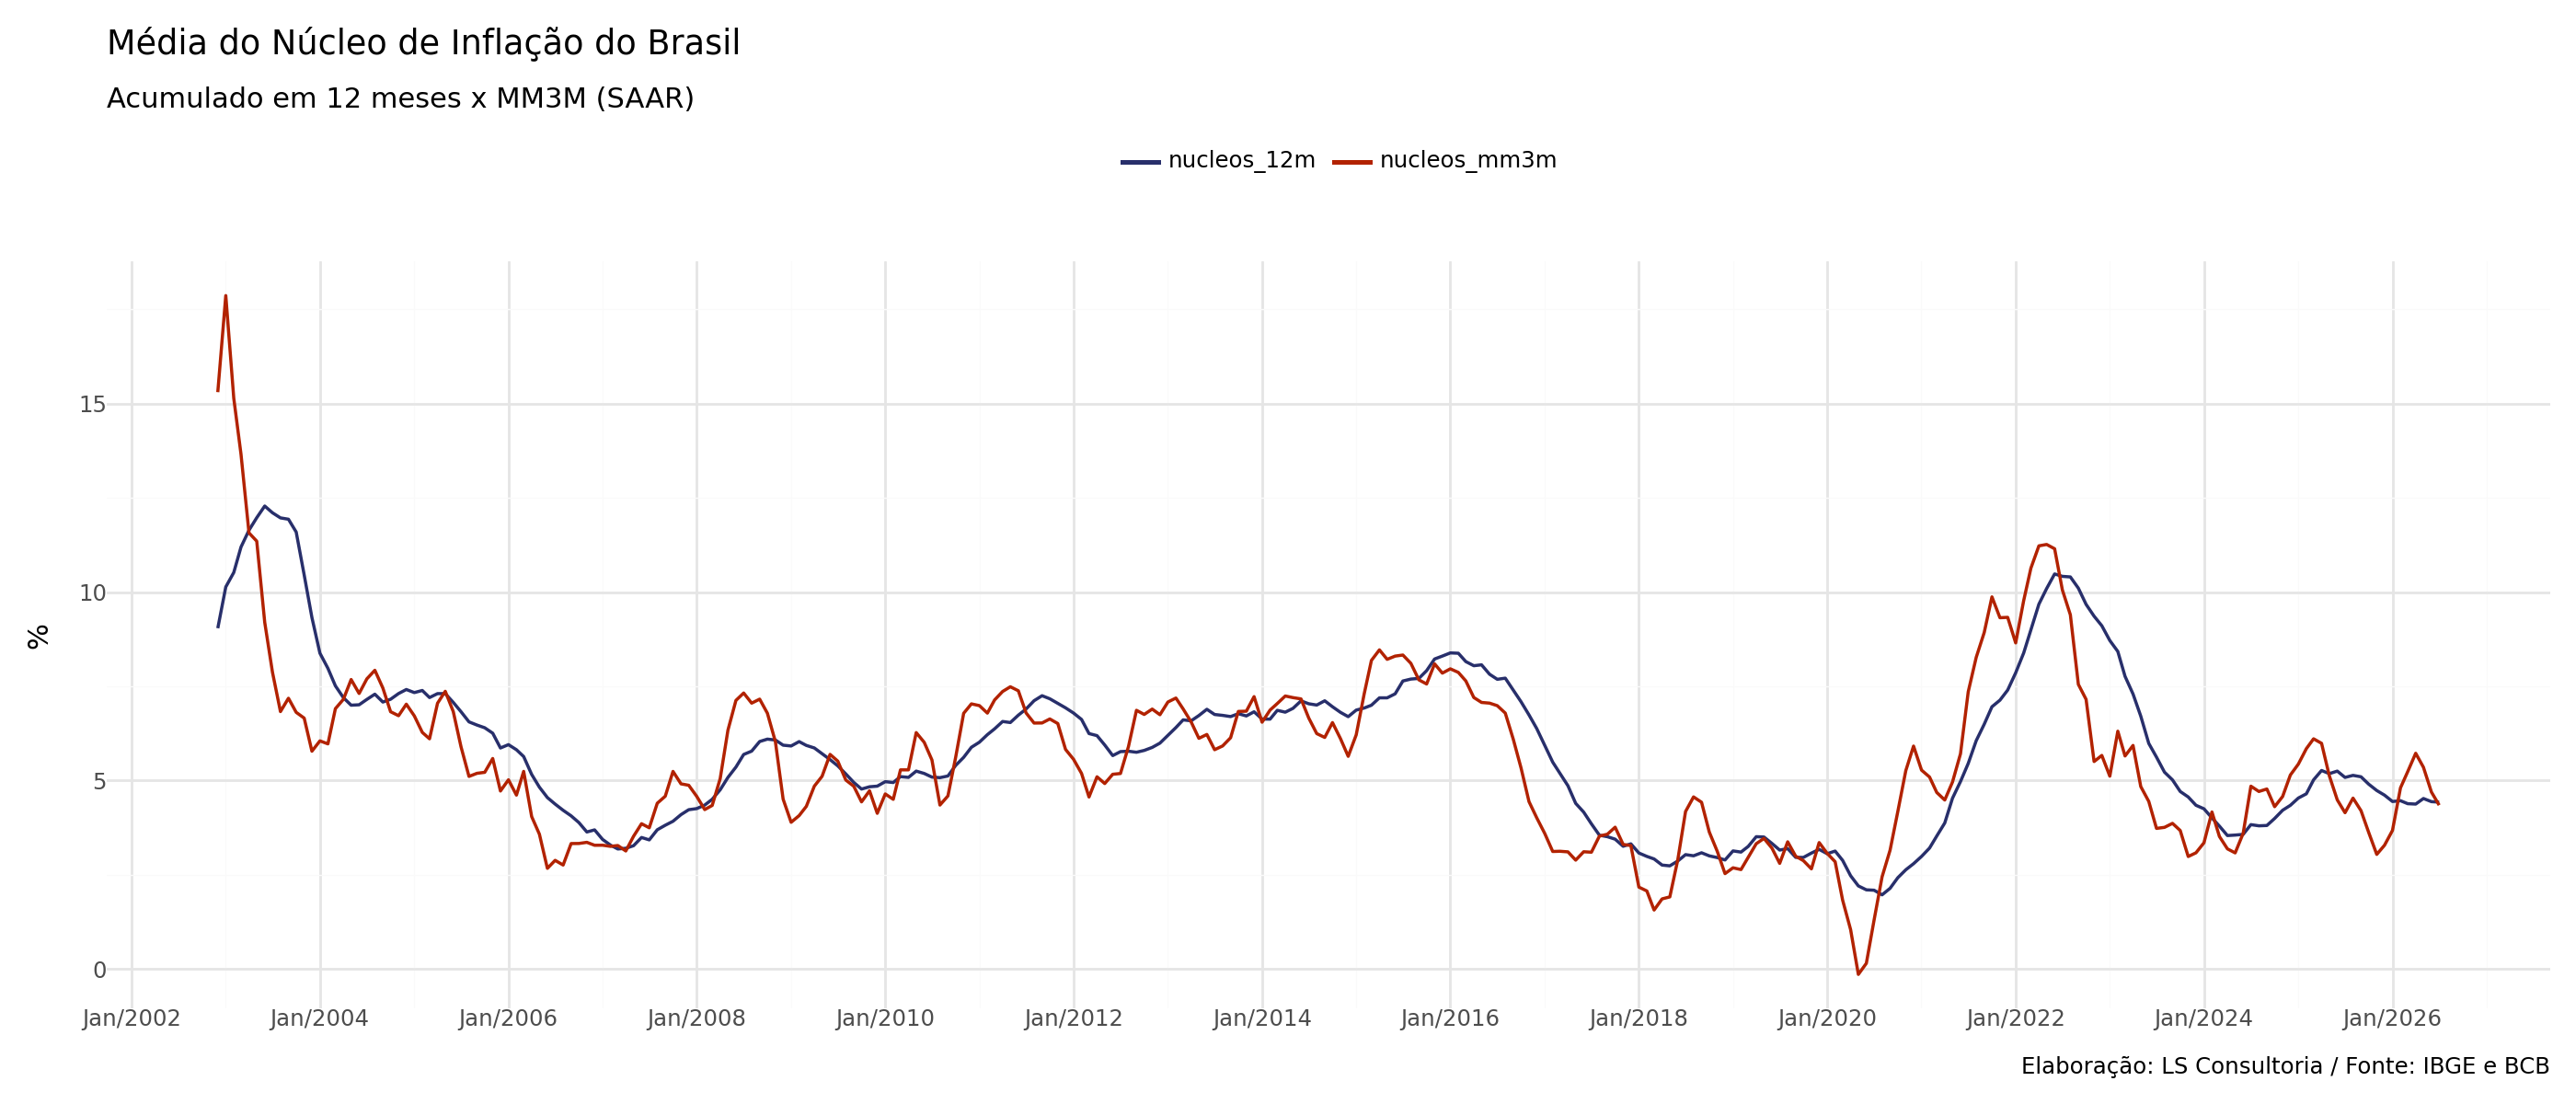

In [ ]:
# 1. Adicione esta nova importação no topo do seu script
from mizani.breaks import breaks_date

# 2. No seu bloco do ggplot, altere a linha do 'scale_x_date' para:
(
    ggplot(dados_long, aes(x = 'Date', y = 'value', color = 'variable')) +
    geom_line(size = 0.7) +
    scale_color_manual(values = list(colors.values())) +

    # ALTERAÇÃO AQUI: usando o breaks_date atualizado
    scale_x_date(breaks = breaks_date(width="2 years"), date_labels = "%b/%Y") +

    labs(title = f"Média do Núcleo de Inflação do Brasil",
         subtitle = "Acumulado em 12 meses x MM3M (SAAR)",
         color = "",
         x="",
         y="%",
         caption = "Elaboração: LS Consultoria / Fonte: IBGE e BCB") +
    theme_minimal() +
    theme(figure_size=(14,6),
          legend_position="top")
)
